In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Reading

In [75]:
df_online_preproc = pd.read_csv('../data/online_shoppers_preproc.csv')
print(df_online_preproc.shape)
df_online_preproc.head()

(12205, 23)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Region,TrafficType,VisitorType,Weekend,Revenue,total_pages,total_duration,product_related_ratio,avg_time_per_page,is_special_period
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,Region_1,Traffic_1,Returning_Visitor,0,0,1,0.000000,1.0,0.000000,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,Region_1,Traffic_2,Returning_Visitor,0,0,2,64.000000,1.0,32.000000,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,Region_9,Traffic_3,Returning_Visitor,0,0,1,0.000000,1.0,0.000000,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,Region_2,Traffic_4,Returning_Visitor,0,0,2,2.666667,1.0,1.333333,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,Region_1,Traffic_4,Returning_Visitor,1,0,10,627.500000,1.0,62.750000,0


# EDA

## Distribución del Target

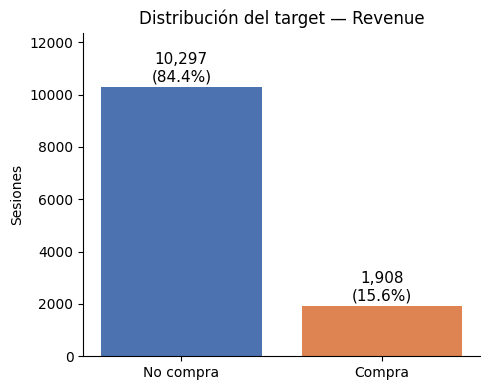

In [76]:
counts = df_online_preproc['Revenue'].value_counts()
pcts   = df_online_preproc['Revenue'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index.map({0: 'No compra', 1: 'Compra'}), counts.values, color=['#4C72B0', '#DD8452'])

for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'{bar.get_height():,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title('Distribución del target — Revenue')
ax.set_ylabel('Sesiones')
ax.set_ylim(0, counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

## Evolución mensual del target

In [77]:
monthly = (
    df_online_preproc
    .groupby(['Month', 'Revenue'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'No compra', 1: 'Compra'})
)

monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100
monthly_pct

Revenue,No compra,Compra
Month,,
Aug,82.448037,17.551963
Dec,87.338804,12.661196
Feb,98.342541,1.657459
Jul,84.722222,15.277778
June,89.824561,10.175439
Mar,89.677419,10.322581
May,89.035746,10.964254
Nov,74.513749,25.486251
Oct,79.052823,20.947177


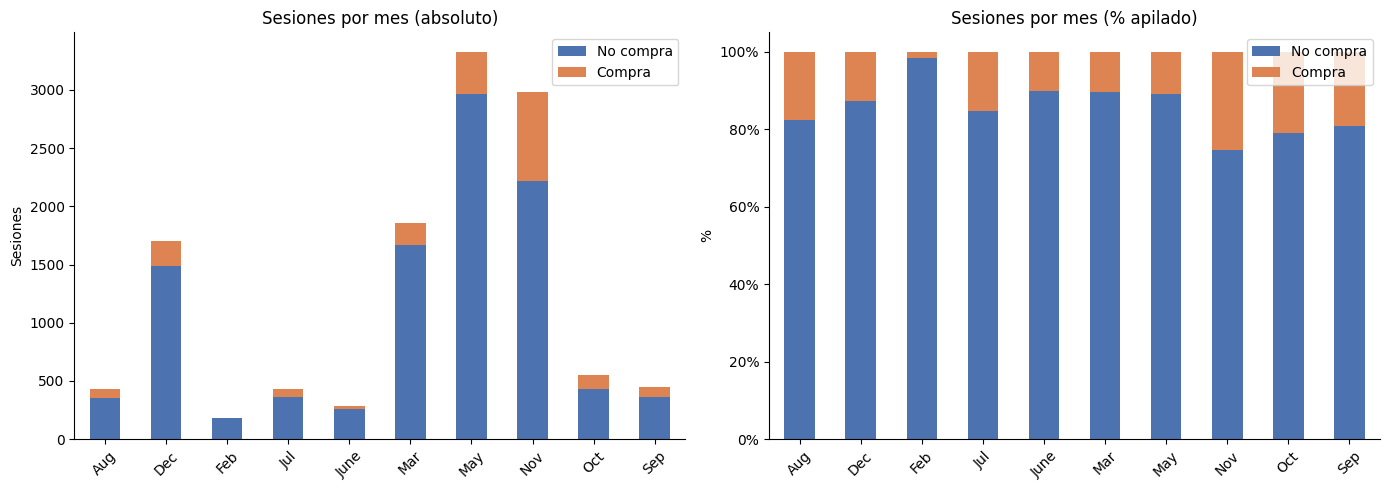

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absoluto
monthly.plot(kind='bar', stacked=True, ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Sesiones por mes (absoluto)')
axes[0].set_ylabel('Sesiones')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='')

# Porcentual
monthly_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Sesiones por mes (% apilado)')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='')

sns.despine()
plt.tight_layout()
plt.show()

## Boxplots

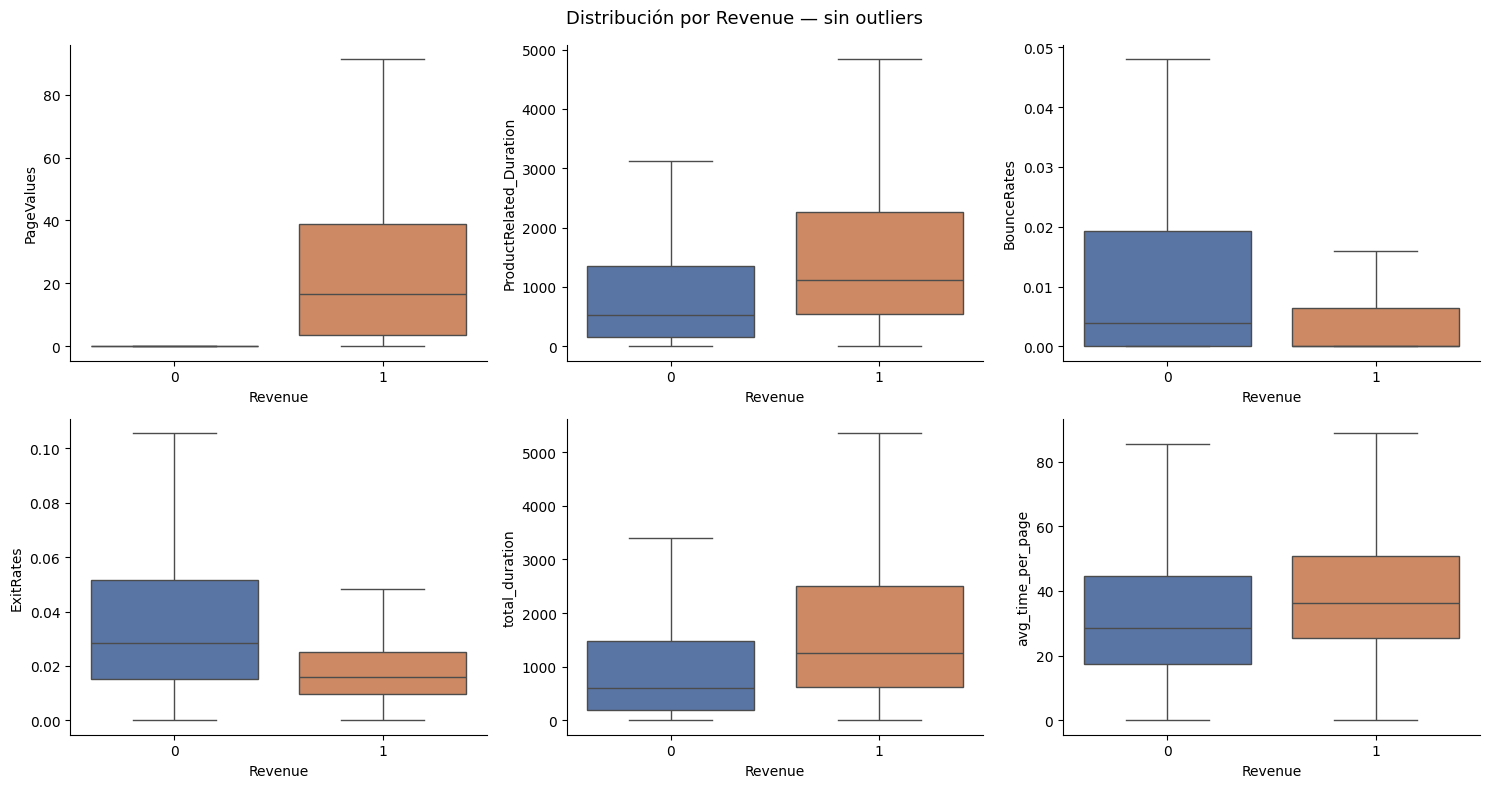

In [79]:
num_feats = ['PageValues', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'total_duration', 'avg_time_per_page']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_feats):
    sns.boxplot(
        data=df_online_preproc,
        x='Revenue',
        y=col,
        hue='Revenue',
        legend=False,
        showfliers=False,
        palette={0: '#4C72B0', 1: '#DD8452'},
        ax=ax,
    )

fig.suptitle('Distribución por Revenue — sin outliers', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

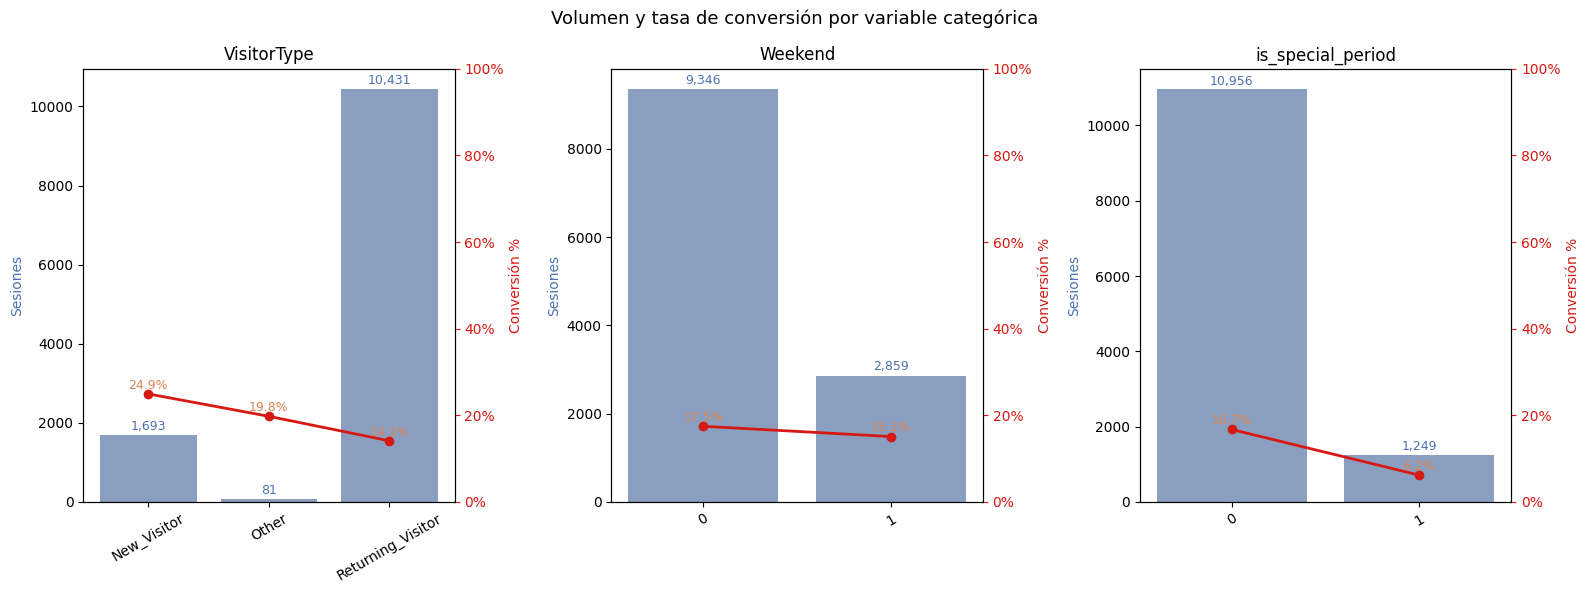

In [80]:
cat_feats = ['VisitorType', 'Weekend', 'is_special_period']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, col in zip(axes, cat_feats):
    stats = (
        df_online_preproc.groupby(col)['Revenue']
        .agg(n='count', conv_rate='mean')
        .assign(conv_rate=lambda d: d['conv_rate'] * 100)
        .sort_values('conv_rate', ascending=False)
        .reset_index()
    )

    # Eje 1 — volumen (barras)
    sns.barplot(data=stats, x=col, y='n', ax=ax, color='#4C72B0', alpha=0.7)
    ax.set_ylabel('Sesiones', color='#4C72B0')
    ax.set_xlabel('')
    ax.set_title(f'{col}')
    ax.tick_params(axis='x', rotation=30)

    # Labels volumen
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=9, color='#4C72B0',
        )

    # Eje 2 — conversion rate (línea)
    ax2 = ax.twinx()
    ax2.plot(range(len(stats)), stats['conv_rate'], color='#D61912', marker='o', linewidth=2)
    ax2.set_ylabel('Conversión %', color="#D61912")
    ax2.set_ylim(0, 100)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.tick_params(axis='y', colors='#D61912')

    # Labels conversion rate
    for i, val in enumerate(stats['conv_rate']):
        ax2.text(i, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='#DD8452')

plt.suptitle('Volumen y tasa de conversión por variable categórica', fontsize=13)
plt.tight_layout()
plt.show()

## Correlation

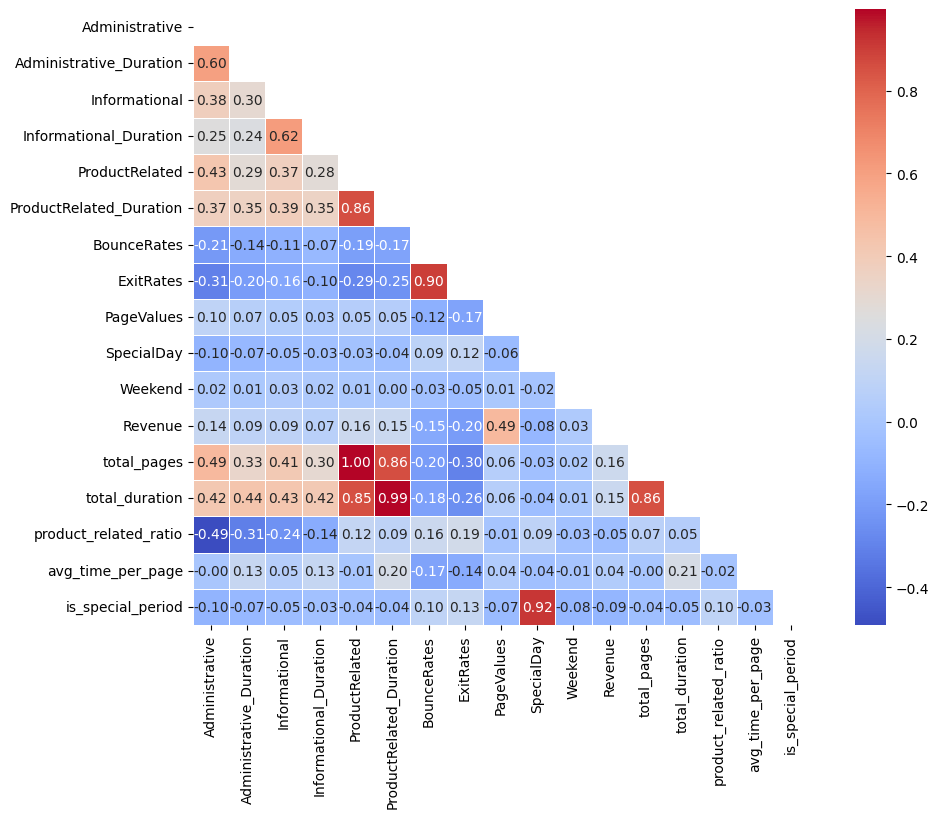

In [81]:
corr = df_online_preproc.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr))

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=.5
)

plt.show()